# Aqui esta la historia de como se me fueron ocurriendo las cosas

In [2]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from matplotlib.colors import ListedColormap

import seaborn as sns

from scipy import stats

from sklearn.preprocessing import MinMaxScaler
from sklearn_extra.cluster import KMedoids

In [3]:
from scripts import style
style.mpl_apply()  

In [4]:
materias = pd.read_excel('data/onedrive/Archivos2024/Materias estudiantes-profesores 2019-2025 P y O.xlsx')
materias_copy = materias.copy()

# Estandarizacion de la base de datos

En esta seccion se estandarizo la base de datos para que no haya alumnos repetidos que inflen la calificacion promedio de un profesor, o de una materia, etc. como los alumnos que revalidan materias y aparecen dos veces en la base de datos. Por ejemplo, yo salgo 2 veces en Calculo, 2 veces en Calculo II, etc.

In [5]:
print(materias.info())
materias.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 27788 entries, 0 to 27787
Data columns (total 9 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   CLAVEALUMNO           27788 non-null  int64  
 1   CLAVECARRERA          27788 non-null  object 
 2   anio                  27788 non-null  int64  
 3   CLAVESESION           27788 non-null  object 
 4   NUMORDEN              27788 non-null  int64  
 5   CLAVEVARIANTEMATERIA  27788 non-null  object 
 6   DESCRIBEMATERIA       27788 non-null  object 
 7   CALIFICACION          27788 non-null  object 
 8   CLAVEPROFESOR         26740 non-null  float64
dtypes: float64(1), int64(3), object(5)
memory usage: 1.9+ MB
None


,CLAVEALUMNO,CLAVECARRERA,anio,CLAVESESION,NUMORDEN,CLAVEVARIANTEMATERIA,DESCRIBEMATERIA,CALIFICACION,CLAVEPROFESOR
0,159167,LAR,2019,OTOÑO,0,MAT1012,MATEMÁTICAS UNIVERSITARIAS,BV,22473.0
1,165277,LAD,2019,OTOÑO,0,MAT1012,MATEMÁTICAS UNIVERSITARIAS,7.6,22473.0
2,162781,LII,2019,OTOÑO,0,MAT1012,MATEMÁTICAS UNIVERSITARIAS,7.5,22473.0
3,161869,LIM,2019,OTOÑO,0,MAT1012,MATEMÁTICAS UNIVERSITARIAS,6.9,22473.0
4,164732,LMK,2019,OTOÑO,0,MAT1012,MATEMÁTICAS UNIVERSITARIAS,RT,22473.0


Hay NaNs en los profes porque son de las revalidadas

In [6]:
def clean_materias_df(materias: pd.DataFrame) -> pd.DataFrame:
    # IF CLAVEPROFESOR is nan and 'CLAVEALUMNO', 'CLAVEVARIANTEMATERIA', 'CALIFICACION' are the same, drop that row
    materias.sort_values(by=['CLAVEALUMNO', 'CLAVEVARIANTEMATERIA', 'CALIFICACION', 'CLAVEPROFESOR'], inplace=True)
    materias.drop_duplicates(subset=['CLAVEALUMNO', 'CLAVEVARIANTEMATERIA', 'CALIFICACION'], keep='first', inplace=True, ignore_index=True)

    # drop NUMORDEN column
    materias.drop(columns=['NUMORDEN'], inplace=True)

    # drop the rows where CLAVEPROFESOR is nan
    materias.dropna(subset=['CLAVEPROFESOR'], inplace=True)
    # make the CLAVEPROFESOR column integer
    materias['CLAVEPROFESOR'] = materias['CLAVEPROFESOR'].astype(int)
    return materias

materias = clean_materias_df(materias)

In [7]:
asesorias = pd.read_excel('data/onedrive/Archivos2024/Asesorias2024.xlsx')

# count how many times each id appears in 'id' column
asesoria_counts = asesorias['id'].value_counts()

# if id in materias['CLAVEALUMNO'] but not in asesoria_counts, assign 0 in materias_counts
asesoria_counts = asesoria_counts.reindex(materias['CLAVEALUMNO'].unique(), fill_value=0)


In [8]:
# clave profesor nunique
profes_value_counts = materias['CLAVEPROFESOR'].value_counts()

# clave profesor nunique
profes_ids = materias['CLAVEPROFESOR'].unique()

In [9]:
def _silverman_bandwidth(x):
    x = np.asarray(x, dtype=float)
    n = len(x)
    if n < 2: return 0.1
    sd = np.std(x, ddof=1)
    q75, q25 = np.percentile(x, [75, 25])
    iqr = q75 - q25
    s = min(sd, iqr/1.34) if iqr > 0 else sd
    h = 0.9 * s * n**(-1/5)
    return max(h, 1e-3)

def _sample_kde_truncated(x_obs, size, low=0.0, high=7.5, rng=None):
    rng = np.random.default_rng() if rng is None else rng
    x_obs = np.asarray(x_obs, dtype=float)
    h = _silverman_bandwidth(x_obs)
    out = np.empty(size, dtype=float); k = 0
    while k < size:
        batch = size - k
        idx = rng.integers(0, len(x_obs), size=batch)
        eps = rng.normal(0.0, h, size=batch)
        draw = x_obs[idx] + eps
        ok = (draw >= low) & (draw <= high)
        take = min(ok.sum(), batch)
        if take:
            out[k:k+take] = draw[ok][:take]
            k += take
    return out

def _sample_empirical(x_obs, size, rng=None):
    rng = np.random.default_rng() if rng is None else rng
    x_obs = np.asarray(x_obs, dtype=float)
    return rng.choice(x_obs, size=size, replace=True)

def impute_nans_from_pre75_kde_df(
    df, value_col='CALIFICACION', out_col='IMPKDE',
    low=0.0, high=7.4, min_kde_n=20, seed=42,
    fallback='uniform',           # 'constant' | 'global' | 'parametric' | 'leave' | 'uniform'
    constant_value=6.5,
    prefer_empirical_if_small=True,
    global_source=None,
    debug=False
):
    rng = np.random.default_rng(seed)
    df = df.copy()

    num = pd.to_numeric(df[value_col], errors='coerce')
    df[out_col] = num
    nan_mask = num.isna()
    need = int(nan_mask.sum())
    if need == 0:
        return df

    obs_pre = num[~num.isna() & (num <= high)]

    def _borrow_pool():
        src = pd.to_numeric(global_source, errors='coerce') if global_source is not None else num
        return src[(~src.isna()) & (src <= high)]

    if len(obs_pre) >= min_kde_n:
        draws = _sample_kde_truncated(obs_pre.values, need, low=low, high=high, rng=rng)
    elif 0 < len(obs_pre) < min_kde_n:
        draws = np.clip(_sample_empirical(obs_pre.values, need, rng=rng), low, high)
    else:
        # No mass in [low, high]; choose fallback
        if fallback == 'global':
            pool = _borrow_pool()
            if len(pool) >= min_kde_n:
                draws = _sample_kde_truncated(pool.values, need, low=low, high=high, rng=rng)
            elif len(pool) > 0:
                draws = np.clip(_sample_empirical(pool.values, need, rng=rng), low, high)
            else:
                draws = np.full(need, min(constant_value, high))
        elif fallback == 'parametric':
            obs_all = num[~num.isna()]
            mu = float(obs_all.mean()) if len(obs_all) else 6.5
            sd = float(obs_all.std(ddof=1)) if len(obs_all) > 1 else 0.5
            sd = max(sd, 1e-3)
            k, draws = 0, np.empty(need)
            while k < need:
                batch = need - k
                cand = rng.normal(mu, sd, size=batch)
                ok = (cand >= low) & (cand <= high)
                take = min(ok.sum(), batch)
                if take:
                    draws[k:k+take] = cand[ok][:take]
                    k += take
        elif fallback == 'uniform':
            # Equally spaced interior points in [low, high]
            # order matches the order of NaNs in the DataFrame
            ks = np.arange(1, need + 1, dtype=float)
            draws = low + (ks / (need + 1.0)) * (high - low)
        elif fallback == 'leave':
            return df
        elif fallback == 'constant':
            draws = np.full(need, min(constant_value, high))
        else:
            raise ValueError("Unknown fallback")

    df.loc[nan_mask, out_col] = draws
    # hard bounds only on imputed entries
    vals = df.loc[nan_mask, out_col].to_numpy(dtype=float, copy=False)
    np.clip(vals, low, high, out=vals)
    df.loc[nan_mask, out_col] = vals
    return df



def get_salones_with_imputations():
    salones = {}

    # group by the 4 keys instead of nested loops
    grouped = materias.groupby(
        ['CLAVEPROFESOR', 'CLAVEVARIANTEMATERIA', 'anio', 'CLAVESESION'],
        sort=False
    )

    for (prof_id, materia, anio, sesion), sesion_materias in grouped:
        # IMPORTANT: work on a copy so assignments are safe
        sesion_materias = sesion_materias.copy()

        # 1) mean-imputation truncated at 7.5
        numeric_calificaciones = pd.to_numeric(
            sesion_materias['CALIFICACION'], errors='coerce'
        )
        mean_calificacion = numeric_calificaciones[
            numeric_calificaciones <= 7.5
        ].mean()

        sesion_materias.loc[:, 'IMPMEAN'] = numeric_calificaciones.fillna(
            mean_calificacion
        )

        mean = sesion_materias['IMPMEAN'].mean()
        std = sesion_materias['IMPMEAN'].std()

        # avoid division by zero just in case
        if std == 0 or pd.isna(std):
            sesion_materias.loc[:, 'IMPMEAN_Z'] = 0.0
        else:
            sesion_materias.loc[:, 'IMPMEAN_Z'] = (
                sesion_materias['IMPMEAN'] - mean
            ) / std

        # 2) KDE-based imputation
        sesion_materias = impute_nans_from_pre75_kde_df(
            sesion_materias,
            value_col='CALIFICACION',
            out_col='IMPKDE',
            constant_value=6.5,
            fallback='uniform',
        )

        mean_kde = sesion_materias['IMPKDE'].mean()
        std_kde = sesion_materias['IMPKDE'].std()

        if std_kde == 0 or pd.isna(std_kde):
            sesion_materias.loc[:, 'IMPKDE_Z'] = 0.0
        else:
            sesion_materias.loc[:, 'IMPKDE_Z'] = (
                sesion_materias['IMPKDE'] - mean_kde
            ) / std_kde

        # store the processed DataFrame
        salones[(prof_id, materia, anio, sesion)] = sesion_materias

    return salones


salones = get_salones_with_imputations()

In [10]:
# if the id of asesorias_counts is in materias['CLAVEALUMNO'], map the count to a new column 'VISITAS' in materias
materias['VISITAS'] = materias['CLAVEALUMNO'].map(asesoria_counts)

# add the timmes each id appears as a new column 'asesoria_count' in asesorias
materias['VISITAS'] = materias['VISITAS'].fillna(0).astype(int)


salon = salones[(23453, 'MAT1012', 2020, 'PRIMAVERA')]
salon['CALIFICACION'] = pd.to_numeric(salon['CALIFICACION'], errors='coerce')

ultramerge = pd.concat(salones.values(), ignore_index=True)
ultramerge['CALIFICACION'] = pd.to_numeric(ultramerge['CALIFICACION'], errors='coerce')

# get the mean of each CLAVEALUMNO in ultramerge
ultramerge_means = ultramerge.groupby('CLAVEALUMNO')['IMPKDE_Z'].mean().reset_index()
ultramerge_means.rename(columns={'IMPKDE_Z': 'MEAN_IMPKDE_Z'}, inplace=True)
ultramerge_means = ultramerge_means.merge(materias[['CLAVEALUMNO', 'VISITAS']].drop_duplicates(), on='CLAVEALUMNO', how='left')
ultramerge['CALIFICACION'] = pd.to_numeric(ultramerge['CALIFICACION'], errors='coerce')
# ultramerge_means.sort_values(by='MEAN_IMPKDE_Z', ascending=False).head(10)

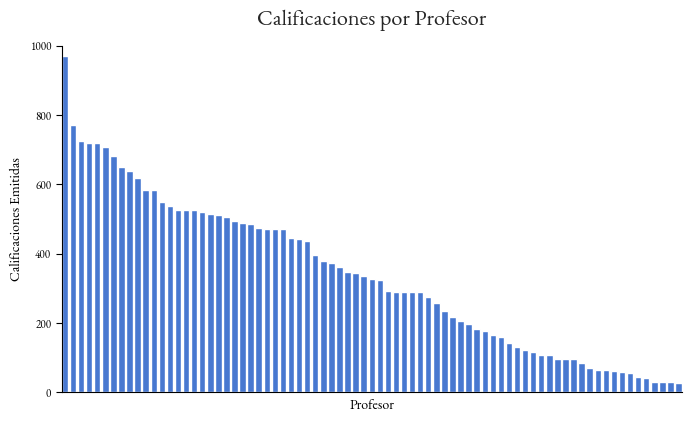

In [11]:
# plot profes_value_counts histogram

plt.bar(profes_value_counts.index.astype(str), profes_value_counts.values)
plt.title('Calificaciones por Profesor')
plt.xlabel('Profesor')
plt.ylabel('Calificaciones Emitidas')
plt.xticks([])
plt.grid(False)
plt.savefig('visualizations/figuras/06_07.pdf', bbox_inches='tight')
plt.show()

Estas ya son mis calificaciones estandarizadas, sin repeticiones de alumnos en las materias.

Bien!

Estas es el numero de alumnos unicos por profesor:  
Hay profesores con 969 alumnos! Wow! y un minimo de 26,30.

# Ver distribucion de calificaciones por profesor!

Se  muestra el KDE porque luego imputaremos valores faltantes y queremos ver la distribucion de calificaciones sin esos valores faltantes.

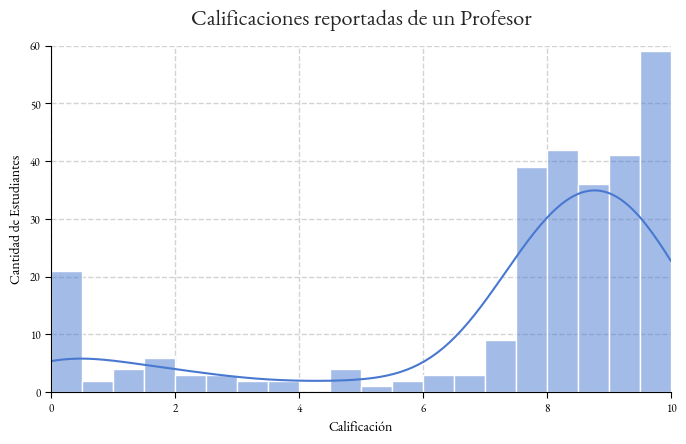

In [12]:
def calificaciones_reportadas_de_un_profesor(clave_profesor: int):
    profe1 = materias[materias['CLAVEPROFESOR'] == clave_profesor]
    # view the rows where CALIFICACION is not numeric
    materias[~materias['CALIFICACION'].apply(lambda x: isinstance(x, (int, float)))]
    # keep the numeric calificacion numeric only
    profe1num = profe1[pd.to_numeric(profe1['CALIFICACION'], errors='coerce').notnull()]

    # plot the histogram of calificacion

    # use seaborn's 'stat' parameter instead of 'density' to avoid Matplotlib/Seaborn incompatibility
    sns.histplot(profe1num['CALIFICACION'].astype(float), bins=20, kde=True)
    plt.title('Calificaciones reportadas de un Profesor')
    plt.xlabel('Calificación')
    plt.ylabel('Cantidad de Estudiantes')
    plt.savefig('visualizations/figuras/06_06.pdf', bbox_inches='tight')
    plt.show()

calificaciones_reportadas_de_un_profesor(22471)

# Ver la distribucion de calificaciones de los profesores

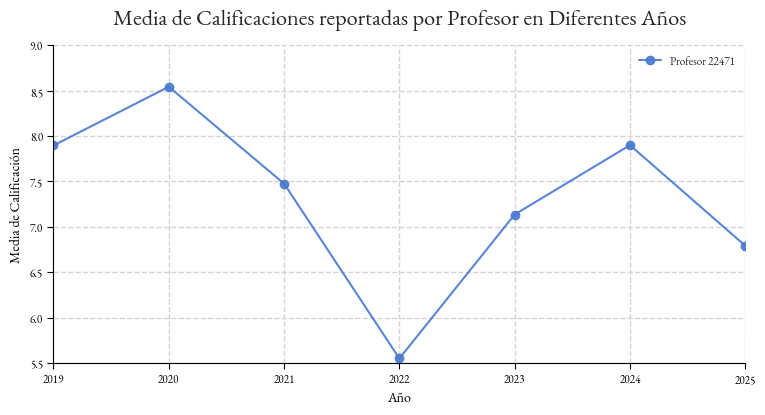

In [13]:
def plot_profe_con_mas_varianza():
    unique_profesores = materias['CLAVEPROFESOR'].nunique()
    unique_profesores

    means = []
    variances = []

    for profe in profes_ids:
        profe_data = materias[materias['CLAVEPROFESOR'] == profe]
        means_by_year = profe_data.groupby('anio')['CALIFICACION'].agg(lambda x: pd.to_numeric(x, errors='coerce').mean())
        means.append(means_by_year)
        variances.append(means_by_year.var())

    # plot the means of each profesor of the top 10 profesores with highest variance
    sorted_indices = np.argsort(variances)[63:-13]
    for i in sorted_indices:
        mean = means[i]
        plt.plot(mean.index, mean.values, marker='o', linestyle='-', label=f'Profesor {profes_ids[i]}', alpha=0.9)
    plt.legend()
    plt.title('Media de Calificaciones reportadas por Profesor en Diferentes Años')
    plt.xlabel('Año')
    plt.ylabel('Media de Calificación')
    plt.tight_layout()
    plt.savefig('visualizations/figuras/06_00.pdf', bbox_inches='tight')
    plt.show()

plot_profe_con_mas_varianza()

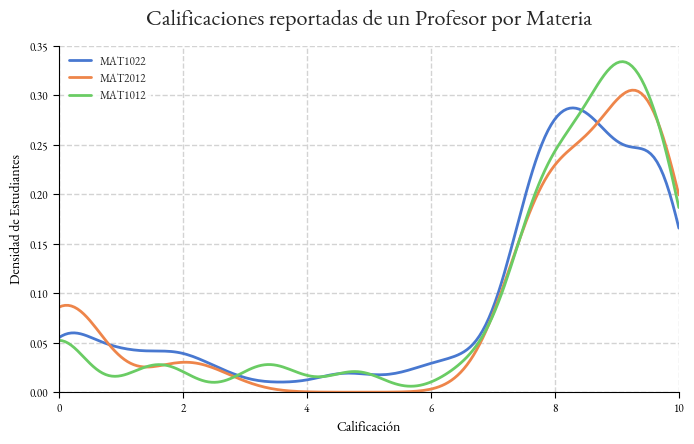

In [14]:
def calificaciones_reportadas_de_un_profesor_por_materia(clave_profesor: int):
    profe1 = materias[materias['CLAVEPROFESOR'] == clave_profesor]
    # view the rows where CALIFICACION is not numeric
    materias[~materias['CALIFICACION'].apply(lambda x: isinstance(x, (int, float)))]
    # keep the numeric calificacion numeric only
    profe1num = profe1[pd.to_numeric(profe1['CALIFICACION'], errors='coerce').notnull()]

    # get unique subjects
    materias_del_profesor = profe1num['CLAVEVARIANTEMATERIA'].unique()
    
    # plot all subjects on the same axes

    for materia in materias_del_profesor:
        profe_materia = profe1num[profe1num['CLAVEVARIANTEMATERIA'] == materia]
        # sns.histplot(profe_materia['CALIFICACION'].astype(float), bins=18, stat='density', alpha=0.5, label=materia)
        sns.kdeplot(profe_materia['CALIFICACION'].astype(float), cut=0, bw_adjust=0.4, fill=False, label=materia, linewidth=2)
    
    plt.title('Calificaciones reportadas de un Profesor por Materia')
    plt.xlabel('Calificación')
    plt.ylabel('Densidad de Estudiantes')
    plt.legend()
    plt.savefig('visualizations/figuras/06_01.pdf', bbox_inches='tight')
    plt.show()

calificaciones_reportadas_de_un_profesor_por_materia(22471)


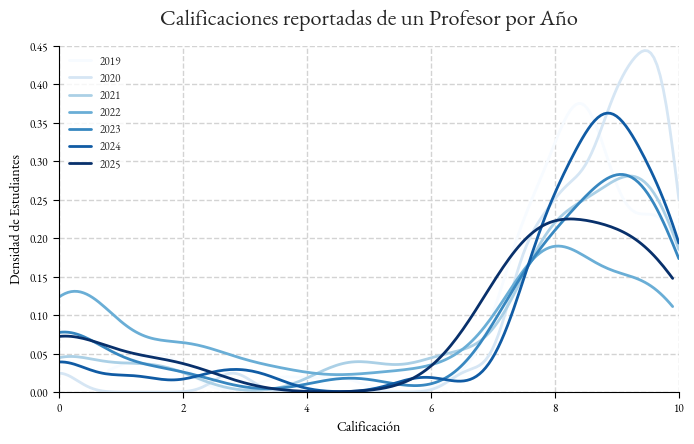

In [15]:
def calificaciones_reportadas_de_un_profesor_por_anio(clave_profesor: int):
    profe1 = materias[materias['CLAVEPROFESOR'] == clave_profesor]
    # view the rows where CALIFICACION is not numeric
    materias[~materias['CALIFICACION'].apply(lambda x: isinstance(x, (int, float)))]
    # keep the numeric calificacion numeric only
    profe1num = profe1[pd.to_numeric(profe1['CALIFICACION'], errors='coerce').notnull()]

    # get unique years and sort them
    anios_del_profesor = sorted(profe1num['anio'].unique())
    
    # create a colormap (Viridis) and normalize years to [0,1]
    cmap = plt.cm.Blues
    norm = plt.Normalize(vmin=min(anios_del_profesor), vmax=max(anios_del_profesor))
    
    # plot all years on the same axes

    for anio in anios_del_profesor:
        profe_anio = profe1num[profe1num['anio'] == anio]
        color = cmap(norm(anio))
        sns.kdeplot(profe_anio['CALIFICACION'].astype(float), cut=0, bw_adjust=0.4, fill=False, label=anio, color=color, linewidth=2)
    
    plt.title('Calificaciones reportadas de un Profesor por Año')
    plt.xlabel('Calificación')
    plt.ylabel('Densidad de Estudiantes')
    plt.legend()
    plt.savefig('visualizations/figuras/06_02.pdf', bbox_inches='tight')
    plt.show()

calificaciones_reportadas_de_un_profesor_por_anio(22471)


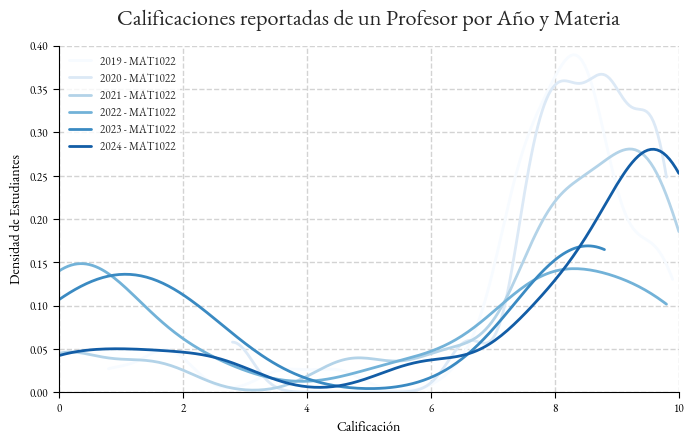

In [16]:
def calificaciones_de_un_profesor_valores_tirados(clave_profesor: int):
    profe1 = materias[materias['CLAVEPROFESOR'] == clave_profesor]
    # view the rows where CALIFICACION is not numeric
    materias[~materias['CALIFICACION'].apply(lambda x: isinstance(x, (int, float)))]
    # keep the numeric calificacion numeric only
    profe1num = profe1[pd.to_numeric(profe1['CALIFICACION'], errors='coerce').notnull()]

    # get unique combinations of anio and CLAVEVARIANTEMATERIA
    unique_combinations = profe1num[['anio', 'CLAVEVARIANTEMATERIA']].drop_duplicates()

    # sort by anio
    unique_combinations.sort_values(by='anio', inplace=True)

    anios_del_profesor = sorted(profe1num['anio'].unique())
    
    # create a colormap (Viridis) and normalize years to [0.2,1]
    cmap = plt.cm.Blues
    norm = plt.Normalize(vmin=min(anios_del_profesor) + 0.2, vmax=max(anios_del_profesor))

    # plot all combinations on the same axes
    for _, row in unique_combinations.iterrows():
        anio = row['anio']
        materia = row['CLAVEVARIANTEMATERIA']
        profe_group = profe1num[(profe1num['anio'] == anio) & (profe1num['CLAVEVARIANTEMATERIA'] == materia)]
        
        if not materia == 'MAT1022':
            continue

        if not profe_group.empty:
            sns.kdeplot(profe_group['CALIFICACION'].astype(float), cut=0, bw_adjust=0.4, fill=False, label=f'{anio} - {materia}', color=cmap(norm(anio)), linewidth=2)
    
    plt.title('Calificaciones reportadas de un Profesor por Año y Materia')
    plt.xlabel('Calificación')
    plt.ylabel('Densidad de Estudiantes')
    plt.legend()
    plt.savefig('visualizations/figuras/06_03.pdf', bbox_inches='tight')
    plt.show()

calificaciones_de_un_profesor_valores_tirados(22471)


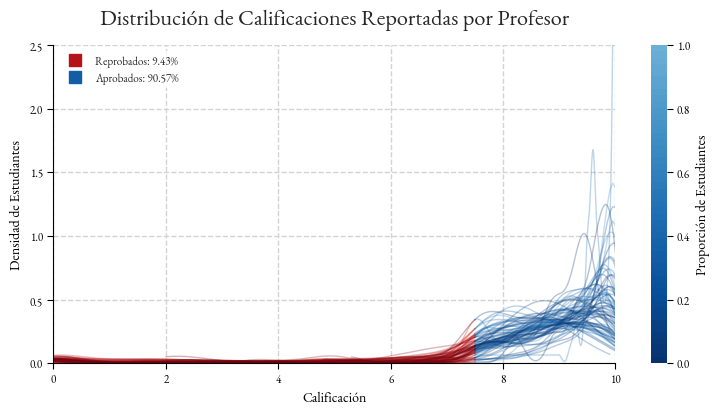

In [19]:


# ---- color scaling by counts (your code kept) ----
scaler = MinMaxScaler()
counts = profes_value_counts.values.reshape(-1, 1)
scaled_counts = scaler.fit_transform(counts)

viridis_by_prof = [sns.color_palette("Blues_r", 100)[int(scaled_counts[i][0]*50)]
                   for i in range(len(scaled_counts))]
magma_by_prof = [sns.color_palette("Reds_r", 100)[int(scaled_counts[i][0]*50)]
                   for i in range(len(scaled_counts))]

threshold = 7.5

# calculate the percentage of CALIFICACION above and below the threshold for each professor
below_threshold_percentages = []
above_threshold_percentages = []
for num in range(len(profes_ids)):
    profe = materias[materias['CLAVEPROFESOR'] == profes_ids[num]]
    profe_num = profe[pd.to_numeric(profe['CALIFICACION'], errors='coerce').notnull()]
    calificaciones = profe_num['CALIFICACION'].astype(float)
    total_count = len(calificaciones)
    if total_count == 0:
        below_threshold_percentages.append(0)
        above_threshold_percentages.append(0)
        continue
    below_count = (calificaciones < threshold).sum()
    above_count = (calificaciones >= threshold).sum()
    below_threshold_percentages.append(below_count / total_count)
    above_threshold_percentages.append(above_count / total_count)

# get the mean
mean_below = np.mean(below_threshold_percentages)
mean_above = np.mean(above_threshold_percentages)

fig, ax = plt.subplots(figsize=(16/2, 9/2))
for num, prof_id in enumerate(profes_ids):

    profe2 = ultramerge[ultramerge['CLAVEPROFESOR'] == prof_id]
    profe2num = profe2[pd.to_numeric(profe2['CALIFICACION'], errors='coerce').notnull()]
    if profe2num.empty:
        continue

    # draw KDE invisibly to obtain its sampled x,y from seaborn
    sns.kdeplot(
        profe2num['CALIFICACION'],
        cut=0, bw_adjust=0.5, clip=(0, 10),
        color='none', linewidth=0, ax=ax
    )
    x, y = ax.lines[-1].get_data()
    ax.lines[-1].remove()  # remove the invisible line

    # ensure x is strictly increasing for interpolation safety
    order = np.argsort(x)
    x, y = x[order], y[order]

    # interpolate y at the split point to avoid a visual gap
    y_thr = np.interp(threshold, x, y)

    # left segment: x <= threshold
    mask_left = x <= threshold
    x_left, y_left = np.append(x[mask_left], threshold), np.append(y[mask_left], y_thr)

    # right segment: x >= threshold
    mask_right = x >= threshold
    x_right, y_right = np.insert(x[mask_right], 0, threshold), np.insert(y[mask_right], 0, y_thr)

    # plot two-tone KDE
    ax.plot(x_left,  y_left,  color=magma_by_prof[num], linewidth=1, alpha=0.3)
    ax.plot(x_right, y_right, color=viridis_by_prof[num], linewidth=1, alpha=0.3)  # put legend label on one segment only


# cosmetics
ax.set_title('Distribución de Calificaciones Reportadas por Profesor')
ax.set_xlabel('Calificación')
ax.set_ylabel('Densidad de Estudiantes')

students_without_calification=ultramerge['CALIFICACION'].isna().sum()

# combine existing legend entries with two custom entries for the means
handles, labels = ax.get_legend_handles_labels()
stat_handles = [
    Line2D([0], [0], marker='s', color=magma_by_prof[35], markersize=8, linestyle=''),
    Line2D([0], [0], marker='s', color=viridis_by_prof[35], markersize=8, linestyle='')
]
stat_labels = [
    f'Reprobados: {mean_below:.2%}',
    f'Aprobados: {mean_above:.2%}'
]
ax.legend(handles + stat_handles, labels + stat_labels, loc='upper left')

ax.set_xlim(0, 10)
ax.set_ylim(0, 2.5)

# add a colorbar only with the range of
# use the same "half" Blues_r palette you used for viridis_by_prof/magma_by_prof
half_palette = sns.color_palette("Blues_r", 100)[:51]
half_cmap = ListedColormap(half_palette)

sm = plt.cm.ScalarMappable(cmap=half_cmap, norm=plt.Normalize(vmin=0, vmax=1))

half_palette = sns.color_palette("Blues_r", 100)[:51]
half_cmap = ListedColormap(half_palette)

sm = plt.cm.ScalarMappable(cmap=half_cmap, norm=plt.Normalize(vmin=0, vmax=1))
sm.set_array([])
# hide the colorbar outline
cbar = plt.colorbar(sm, ax=ax, label='Proporción de Estudiantes')
cbar.outline.set_visible(False)

plt.tight_layout()

plt.savefig('visualizations/figuras/05_06.pdf', bbox_inches='tight')
plt.show()

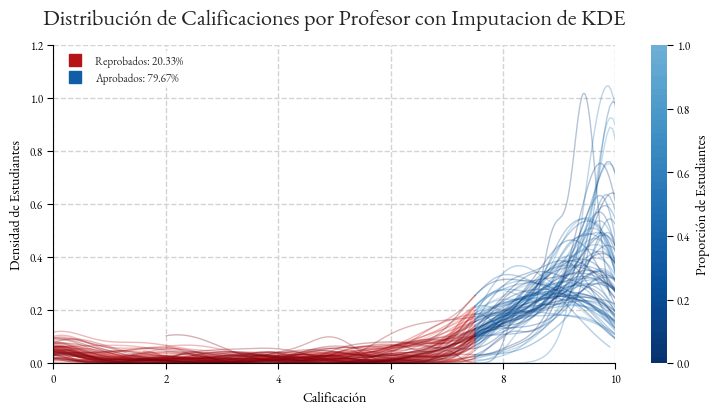

In [20]:
fig, ax = plt.subplots(figsize=(16/2, 9/2))

for num, prof_id in enumerate(profes_ids):
    profe2 = ultramerge[ultramerge['CLAVEPROFESOR'] == prof_id]
    profe2num = profe2[pd.to_numeric(profe2['IMPKDE'], errors='coerce').notnull()]
    if profe2num.empty:
        continue

    # draw KDE invisibly to obtain its sampled x,y from seaborn
    sns.kdeplot(
        profe2num['IMPKDE'],
        cut=0, bw_adjust=0.5, clip=(0, 10),
        color='none', linewidth=0, ax=ax
    )
    x, y = ax.lines[-1].get_data()
    ax.lines[-1].remove()  # remove the invisible line

    # ensure x is strictly increasing for interpolation safety
    order = np.argsort(x)
    x, y = x[order], y[order]

    # interpolate y at the split point to avoid a visual gap
    y_thr = np.interp(threshold, x, y)

    # left segment: x <= threshold
    mask_left = x <= threshold
    x_left, y_left = np.append(x[mask_left], threshold), np.append(y[mask_left], y_thr)

    # right segment: x >= threshold
    mask_right = x >= threshold
    x_right, y_right = np.insert(x[mask_right], 0, threshold), np.insert(y[mask_right], 0, y_thr)

    # plot two-tone KDE
    ax.plot(x_left,  y_left,  color=magma_by_prof[num], linewidth=1, alpha=0.3)
    ax.plot(x_right, y_right, color=viridis_by_prof[num], linewidth=1, alpha=0.3)  # put legend label on one segment only


# cosmetics
ax.set_title('Distribución de Calificaciones por Profesor con Imputacion de KDE')
ax.set_xlabel('Calificación')
ax.set_ylabel('Densidad de Estudiantes')

# combine existing legend entries with two custom entries for the means
handles, labels = ax.get_legend_handles_labels()
stat_handles = [
    Line2D([0], [0], marker='s', color=magma_by_prof[35], markersize=8, linestyle=''),
    Line2D([0], [0], marker='s', color=viridis_by_prof[35], markersize=8, linestyle='')
]

mean_below = (ultramerge['IMPKDE'] < threshold).mean()
mean_above = (ultramerge['IMPKDE'] >= threshold).mean()
stat_labels = [
    f'Reprobados: {mean_below:.2%}',
    f'Aprobados: {mean_above:.2%}'
]
ax.legend(handles + stat_handles, labels + stat_labels, loc='upper left')

ax.set_xlim(0, 10)
#  ax.set_ylim(0, 2.5)

# add a colorbar only with the range of
# use the same "half" Blues_r palette you used for viridis_by_prof/magma_by_prof
half_palette = sns.color_palette("Blues_r", 100)[:51]
half_cmap = ListedColormap(half_palette)

sm = plt.cm.ScalarMappable(cmap=half_cmap, norm=plt.Normalize(vmin=0, vmax=1))

half_palette = sns.color_palette("Blues_r", 100)[:51]
half_cmap = ListedColormap(half_palette)

sm = plt.cm.ScalarMappable(cmap=half_cmap, norm=plt.Normalize(vmin=0, vmax=1))
sm.set_array([])
cbar = plt.colorbar(sm, ax=ax, label='Proporción de Estudiantes')
cbar.outline.set_visible(False)


plt.tight_layout()

plt.savefig('visualizations/figuras/05_07.pdf', bbox_inches='tight')
plt.show()

# KS cluster para agrupar profesores por similitud en distribucion de calificaciones

In [21]:
# 0) isolate valid data and enforce support
df = ultramerge[['CLAVEPROFESOR','IMPKDE']].copy()
df['IMPKDE'] = pd.to_numeric(df['IMPKDE'], errors='coerce')
df = df.dropna(subset=['IMPKDE'])
df['IMPKDE'] = df['IMPKDE'].clip(0, 10)

# 1) keep professors with enough observations
nmin = 25  # adjust
counts = df.groupby('CLAVEPROFESOR').size()
keep = counts[counts >= nmin].index
df = df[df['CLAVEPROFESOR'].isin(keep)]
prof_ids = keep.to_list()

# 2) compute pairwise KS effect sizes, group by professor and store values in a dict
groups = {k: v.values for k, v in df.groupby('CLAVEPROFESOR')['IMPKDE']}
m = len(prof_ids)
D = np.zeros((m, m), dtype=float)

for a in range(m):
    xa = groups[prof_ids[a]]
    for b in range(a+1, m):
        xb = groups[prof_ids[b]]
        ks_stat, _ = stats.ks_2samp(xa, xb, alternative='two-sided', method='auto')
        D[a, b] = D[b, a] = ks_stat  # distance in [0,1]
# diagonal already zeros



In [22]:

# this in a dataframe for convenience
D_df = pd.DataFrame(D, index=prof_ids, columns=prof_ids)

c:\Users\herie\miniconda3\envs\CMAT\Lib\site-packages\seaborn\matrix.py:530: ClusterWarning: The symmetric non-negative hollow observation matrix looks suspiciously like an uncondensed distance matrix
  linkage = hierarchy.linkage(self.array, method=self.method,
c:\Users\herie\miniconda3\envs\CMAT\Lib\site-packages\seaborn\matrix.py:530: ClusterWarning: The symmetric non-negative hollow observation matrix looks suspiciously like an uncondensed distance matrix
  linkage = hierarchy.linkage(self.array, method=self.method,


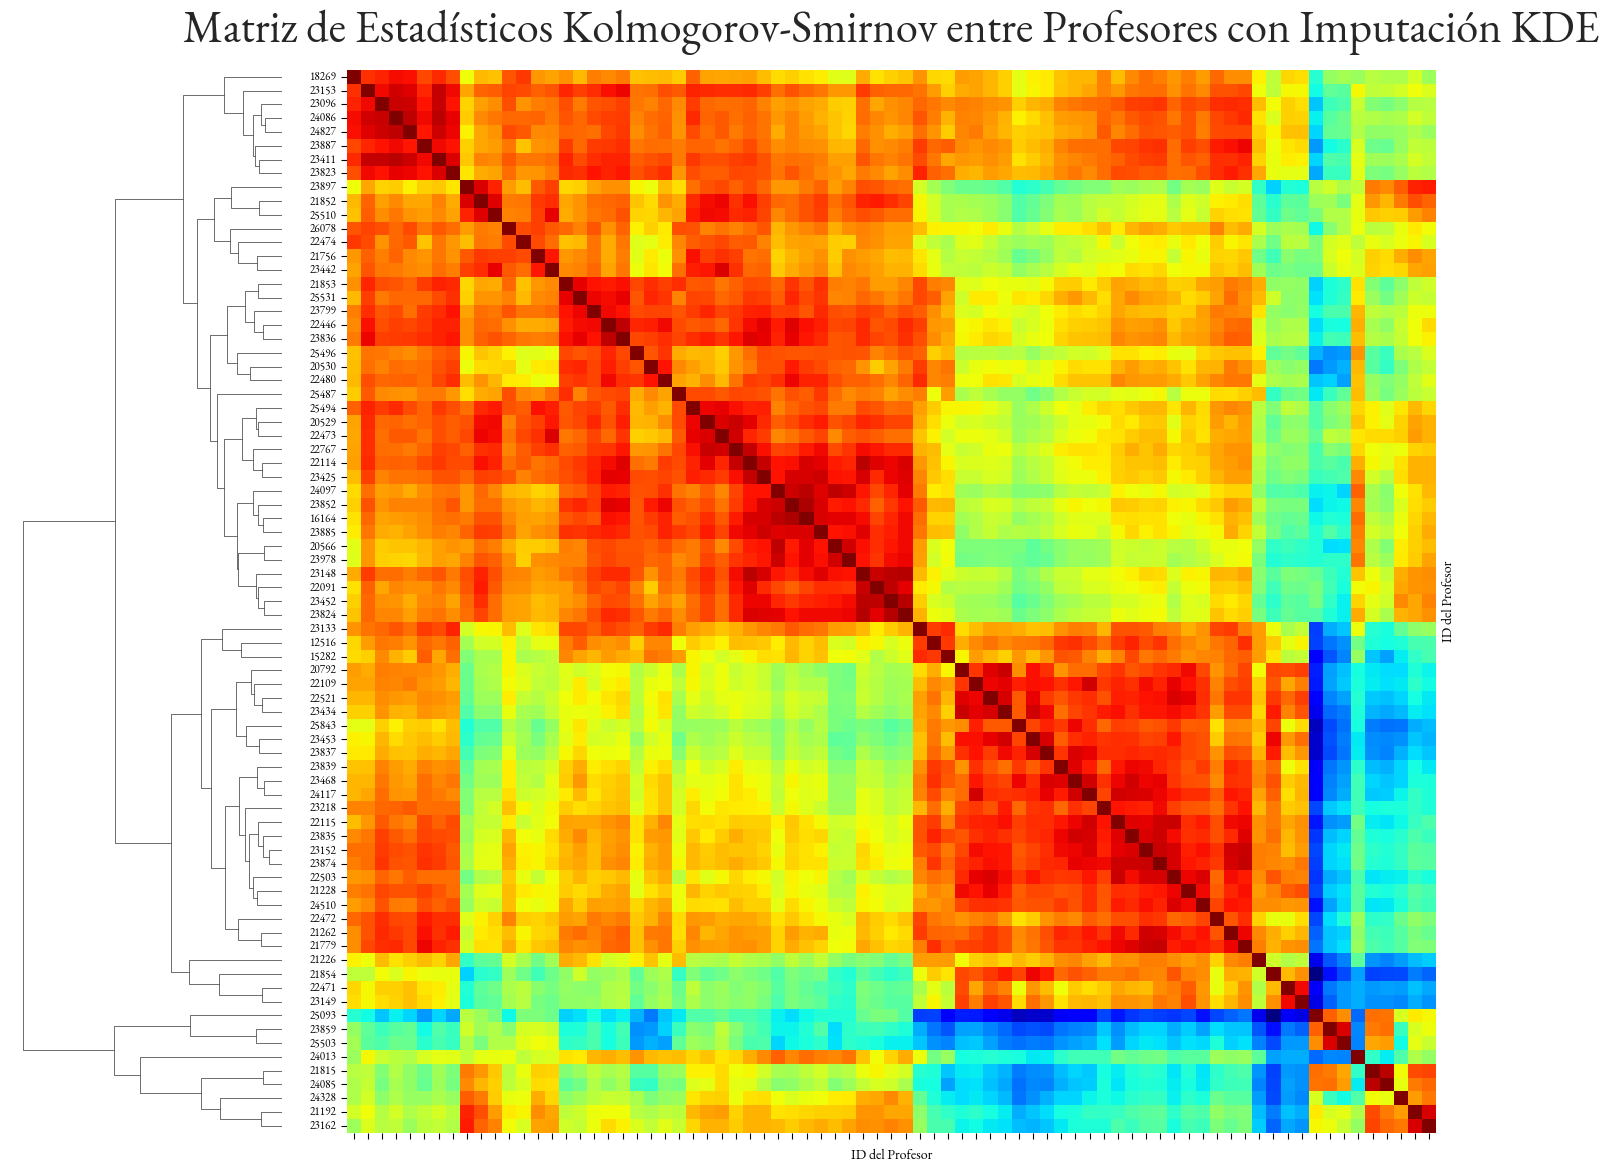

In [23]:
# plot the ks_matrix as a clustermap heatmap
# seaborn.clustermap creates its own figure and colorbar; capture the returned ClusterGrid

g = sns.clustermap(D_df, cmap='jet_r', annot=False, figsize=(15, 15), xticklabels=True, yticklabels=True)

# set titles/labels on the heatmap axis
g.ax_heatmap.set_title('Matriz de Estadísticos Kolmogorov-Smirnov entre Profesores con Imputación KDE', pad=20, fontsize=32)
g.ax_heatmap.set_xlabel('ID del Profesor')
g.ax_heatmap.set_ylabel('ID del Profesor')

# rotate tick labels and set small font
g.ax_heatmap.set_xticklabels(g.ax_heatmap.get_xticklabels(), rotation=90, fontsize=8)
g.ax_heatmap.set_yticklabels(g.ax_heatmap.get_yticklabels(), rotation=0, fontsize=8)

# set colorbar label using the clustergrid's cax (colorbar axis)
# if hasattr(g, 'cax') and g.cax is not None:
# hide colorbar
if hasattr(g, 'cax') and g.cax is not None:
    g.cax.set_visible(False)
	
# hide the top cluster dendrogram
g.ax_col_dendrogram.set_visible(False)

# move the labels from right side to left side
g.ax_heatmap.yaxis.set_label_position("right")
g.ax_heatmap.yaxis.tick_left()
g.ax_heatmap.yaxis.set_ticks_position("left")

# dont show x tick labels 
g.ax_heatmap.xaxis.set_ticklabels([])

plt.tight_layout()

plt.savefig('visualizations/figuras/05_08.pdf', bbox_inches='tight')
plt.show()

el estadistico KS mide la distancia maxima entre dos funciones de distribucion acumulada. En este caso, se usa para medir la diferencia entre las distribuciones de calificaciones de diferentes profesores. Un valor KS bajo indica que las distribuciones son similares, mientras que un valor alto indica diferencias significativas.

Si el KS se acerca a 0, las distribuciones de calificaciones de los dos profesores son muy similares. Si el KS se acerca a 1, las distribuciones son muy diferentes.

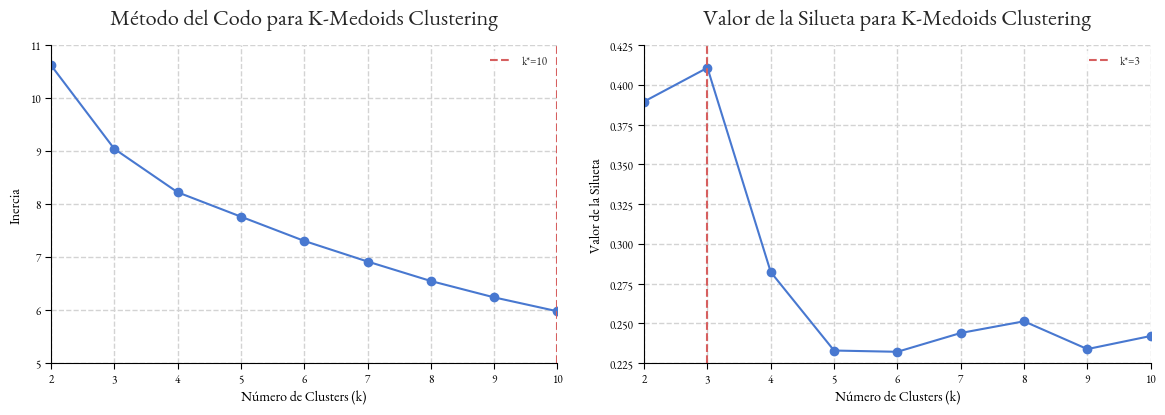

In [24]:
from sklearn_extra.cluster import KMedoids
from sklearn.metrics import silhouette_score

ks = range(2, 11)
elbow, sils = [], []

for k in ks:
    best_inertia, best_labels = np.inf, None
    for seed in range(20):
        km = KMedoids(n_clusters=k, metric='precomputed', method='pam',
                      init='k-medoids++', random_state=seed)
        km.fit(D)
        if km.inertia_ < best_inertia:
            best_inertia = km.inertia_
            best_labels  = km.labels_
    elbow.append(best_inertia)
    sils.append(silhouette_score(D, best_labels, metric='precomputed'))

k_star_elbow = ks[int(np.argmin(np.gradient(np.gradient(elbow))))]  # knee by curvature
k_star_sil   = ks[int(np.argmax(sils))]


plt.figure(figsize=(24/2, 9/2))
plt.subplot(1, 2, 1)    
plt.plot(ks, elbow, marker='o')
plt.axvline(k_star_elbow, color='r', linestyle='--', label=f'k*={k_star_elbow}')
plt.title('Método del Codo para K-Medoids Clustering')
plt.xlabel('Número de Clusters (k)')
plt.ylabel('Inercia')
plt.legend(loc='upper right')
plt.subplot(1, 2, 2)    
plt.plot(ks, sils, marker='o')
plt.axvline(k_star_sil, color='r', linestyle='--', label=f'k*={k_star_sil}')
plt.title('Valor de la Silueta para K-Medoids Clustering')  
plt.xlabel('Número de Clusters (k)')
plt.ylabel('Valor de la Silueta')
plt.legend()
plt.tight_layout()

plt.savefig('visualizations/figuras/05_09.pdf', bbox_inches='tight')
plt.show()

# Distribuciones de calificaciones de profesores por clusters

In [25]:
# cluster with k=4
kmedoids = KMedoids(n_clusters=3, random_state=42)
kmedoids.fit(D_df.to_numpy())
ultramerge['KS_CLUSTER'] = ultramerge['CLAVEPROFESOR'].map(
    dict(zip(D_df.index, kmedoids.labels_))
)

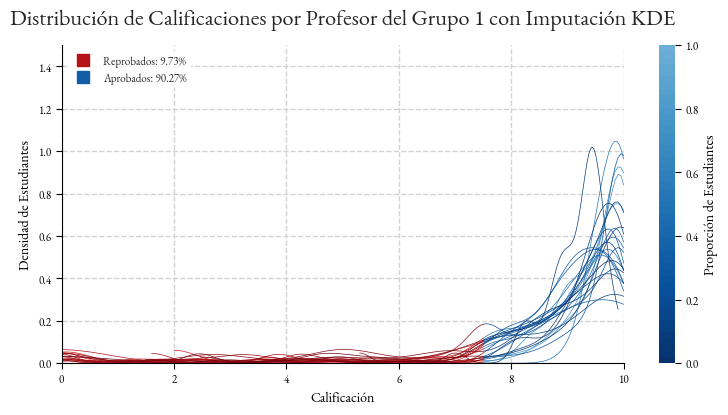

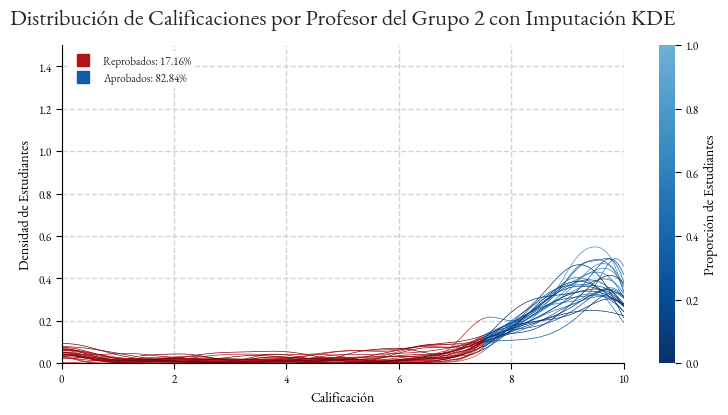

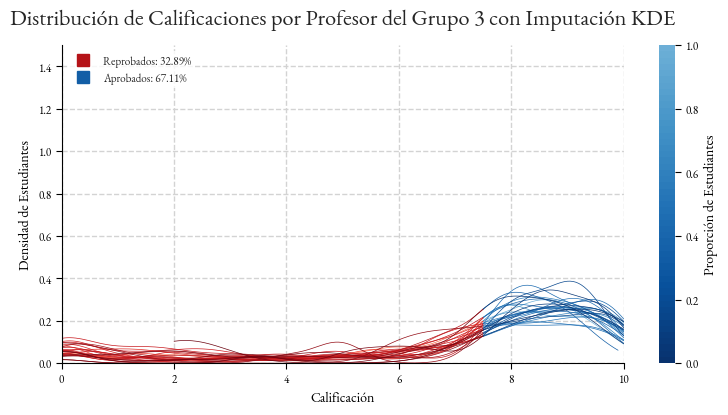

In [26]:
for i in range(3):

    fig, ax = plt.subplots(figsize=(16/2, 9/2))

    k1 = ultramerge[ultramerge['KS_CLUSTER'] == i]

    for num, prof_id in enumerate(profes_ids):
        profe2 = k1[k1['CLAVEPROFESOR'] == prof_id]
        profe2num = profe2[pd.to_numeric(profe2['IMPKDE'], errors='coerce').notnull()]
        if profe2num.empty:
            continue

        # draw KDE invisibly to obtain its sampled x,y from seaborn
        sns.kdeplot(
            profe2num['IMPKDE'],
            cut=0, bw_adjust=0.5, clip=(0, 10),
            color='none', linewidth=0, ax=ax
        )
        x, y = ax.lines[-1].get_data()
        ax.lines[-1].remove()  # remove the invisible line

        # ensure x is strictly increasing for interpolation safety
        order = np.argsort(x)
        x, y = x[order], y[order]

        # interpolate y at the split point to avoid a visual gap
        y_thr = np.interp(threshold, x, y)

        # left segment: x <= threshold
        mask_left = x <= threshold
        x_left, y_left = np.append(x[mask_left], threshold), np.append(y[mask_left], y_thr)

        # right segment: x >= threshold
        mask_right = x >= threshold
        x_right, y_right = np.insert(x[mask_right], 0, threshold), np.insert(y[mask_right], 0, y_thr)

        # plot two-tone KDE
        ax.plot(x_left,  y_left,  color=magma_by_prof[num], linewidth=0.5, alpha=1)
        ax.plot(x_right, y_right, color=viridis_by_prof[num], linewidth=0.5, alpha=1)  # put legend label on one segment only


    # cosmetics
    ax.set_title(f'Distribución de Calificaciones por Profesor del Grupo {i+1} con Imputación KDE')
    ax.set_xlabel('Calificación')
    ax.set_ylabel('Densidad de Estudiantes')

    # combine existing legend entries with two custom entries for the means
    handles, labels = ax.get_legend_handles_labels()
    stat_handles = [
        Line2D([0], [0], marker='s', color=magma_by_prof[35], markersize=8, linestyle=''),
        Line2D([0], [0], marker='s', color=viridis_by_prof[35], markersize=8, linestyle='')
    ]
    mean_below = (k1['IMPKDE'] < threshold).mean()
    mean_above = (k1['IMPKDE'] >= threshold).mean()
    stat_labels = [
        f'Reprobados: {mean_below:.2%}',
        f'Aprobados: {mean_above:.2%}'
    ]
    ax.legend(handles + stat_handles, labels + stat_labels, loc='upper left')

    ax.set_xlim(0, 10)
    ax.set_ylim(0, 1.5)

    # add a colorbar only with the range of
    # use the same "half" Blues_r palette you used for viridis_by_prof/magma_by_prof
    half_palette = sns.color_palette("Blues_r", 100)[:51]
    half_cmap = ListedColormap(half_palette)

    sm = plt.cm.ScalarMappable(cmap=half_cmap, norm=plt.Normalize(vmin=0, vmax=1))

    half_palette = sns.color_palette("Blues_r", 100)[:51]
    half_cmap = ListedColormap(half_palette)

    sm = plt.cm.ScalarMappable(cmap=half_cmap, norm=plt.Normalize(vmin=0, vmax=1))
    sm.set_array([])
    cbar = plt.colorbar(sm, ax=ax, label='Proporción de Estudiantes')
    cbar.outline.set_visible(False)


    plt.tight_layout()
    plt.savefig(f'visualizations/figuras/05_10_{i}.pdf', bbox_inches='tight')
    plt.show()

# Distribuciones con intervalos de confianza por clusters de profesores

In [27]:
SQRT_2PI = np.sqrt(2*np.pi)

def silverman_bandwidth(x):
    x = np.asarray(x, dtype=float)
    n = len(x)
    if n < 2:
        return 0.1
    sd = np.std(x, ddof=1)
    q75, q25 = np.percentile(x, [75, 25])
    iqr = q75 - q25
    s = sd if iqr <= 0 else min(sd, iqr/1.34)
    return 0.9 * s * n**(-1/5)

def kde_gaussian_grid(x_grid, sample, h):
    # x_grid: (m,), sample: (n,), returns f_hat(x_grid): (m,)
    Z = (x_grid[:, None] - sample[None, :]) / h        # (m,n)
    return np.exp(-0.5 * Z**2).sum(axis=1) / (len(sample) * h * SQRT_2PI)

def kde_bootstrap_ci(x_grid, sample, h, B=200, q=(2.5, 97.5), rng=None):
    rng = np.random.default_rng(None if rng is None else rng)
    n = len(sample)
    m = len(x_grid)
    boot = np.empty((B, m), dtype=float)
    idx = np.arange(n)
    for b in range(B):
        resample = sample[rng.integers(0, n, n)]
        boot[b] = kde_gaussian_grid(x_grid, resample, h)
    lo, hi = np.percentile(boot, q, axis=0)
    return lo, hi


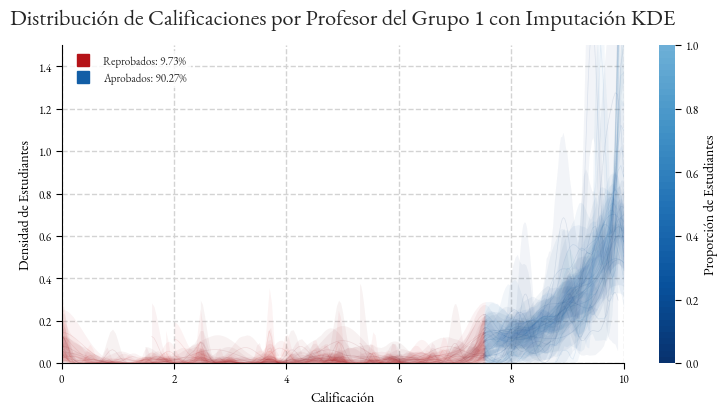

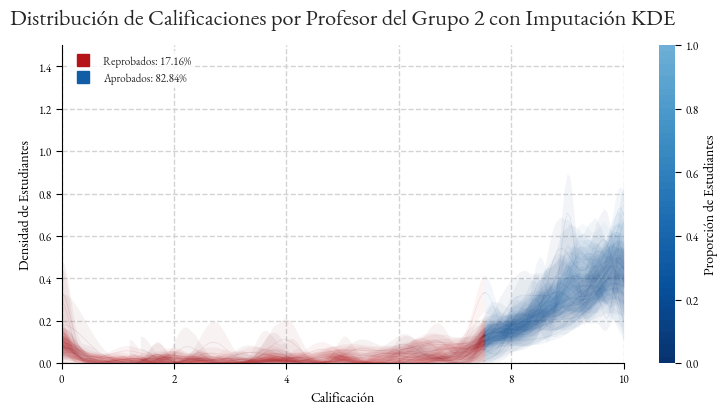

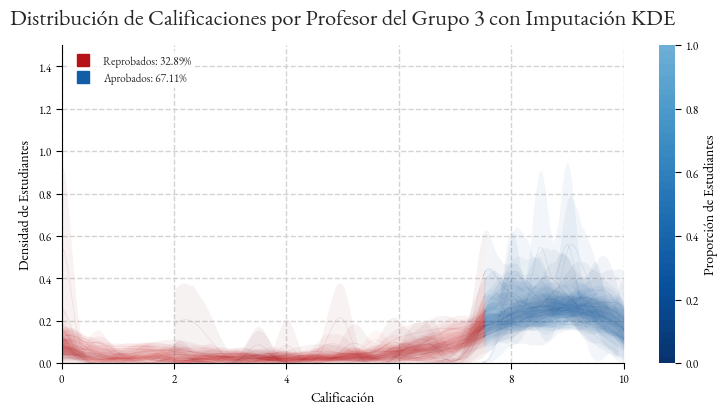

In [28]:
for i in range(3):
    fig, ax = plt.subplots(figsize=(16/2, 9/2))
    k1 = ultramerge[ultramerge['KS_CLUSTER'] == i]

    bw_adj = 0.5
    B = 200          # bootstrap replicates
    alpha_line = 0.1
    alpha_band = 0.05

    for num, prof_id in enumerate(profes_ids):
        profe2 = k1[k1['CLAVEPROFESOR'] == prof_id]
        profe2num = profe2[pd.to_numeric(profe2['IMPKDE'], errors='coerce').notnull()]['IMPKDE'].to_numpy(float)
        if profe2num.size == 0:
            continue

        # draw KDE invisibly to obtain seaborn's grid
        sns.kdeplot(
            profe2num, cut=0, bw_adjust=bw_adj, clip=(0, 10),
            color='none', linewidth=0, ax=ax
        )
        x, y = ax.lines[-1].get_data()
        ax.lines[-1].remove()

        # ensure sorted grid
        order = np.argsort(x)
        x, y = x[order], y[order]

        # bandwidth: Silverman * bw_adjust on this professor's data
        h = silverman_bandwidth(profe2num) * bw_adj
        # point estimate on the same grid (to match CI computation exactly)
        y_hat = kde_gaussian_grid(x, profe2num, h)

        # bootstrap CIs at each x
        lo, hi = kde_bootstrap_ci(x, profe2num, h, B=B, q=(2.5, 97.5), rng=42)

        # split at threshold
        y_thr = np.interp(threshold, x, y_hat)

        mask_left = x <= threshold + 0.06
        mask_right = x >= threshold

        # close the split so bands do not gap
        x_left  = np.append(x[mask_left],  threshold)
        yh_left = np.append(y_hat[mask_left], y_thr)
        lo_left = np.append(lo[mask_left],   y_thr)  # conservative join
        hi_left = np.append(hi[mask_left],   y_thr)

        x_right  = np.insert(x[mask_right],  0, threshold)
        yh_right = np.insert(y_hat[mask_right], 0, y_thr)
        lo_right = np.insert(lo[mask_right],   0, y_thr)
        hi_right = np.insert(hi[mask_right],   0, y_thr)

        # plot bands first, then lines
        ax.fill_between(x_left,  lo_left,  hi_left,
                        color=magma_by_prof[num], alpha=alpha_band, linewidth=0)
        ax.fill_between(x_right, lo_right, hi_right,
                        color=viridis_by_prof[num], alpha=alpha_band, linewidth=0)

        ax.plot(x_left,  yh_left,  color=magma_by_prof[num],  linewidth=0.5, alpha=alpha_line)
        ax.plot(x_right, yh_right, color=viridis_by_prof[num], linewidth=0.5, alpha=alpha_line)

    # cosmetics unchanged
    ax.set_title(f'Distribución de Calificaciones por Profesor del Grupo {i+1} con Imputación KDE')
    ax.set_xlabel('Calificación')
    ax.set_ylabel('Densidad de Estudiantes')

    handles, labels = ax.get_legend_handles_labels()
    stat_handles = [
        Line2D([0], [0], marker='s', color=magma_by_prof[35], markersize=8, linestyle=''),
        Line2D([0], [0], marker='s', color=viridis_by_prof[35], markersize=8, linestyle='')
    ]
    mean_below = (k1['IMPKDE'] < threshold).mean()
    mean_above = (k1['IMPKDE'] >= threshold).mean()
    stat_labels = [f'Reprobados: {mean_below:.2%}', f'Aprobados: {mean_above:.2%}']
    ax.legend(handles + stat_handles, labels + stat_labels, loc='upper left')

    ax.set_xlim(0, 10)
    ax.set_ylim(0, 1.5)

    half_palette = sns.color_palette("Blues_r", 100)[:51]
    half_cmap = ListedColormap(half_palette)
    sm = plt.cm.ScalarMappable(cmap=half_cmap, norm=plt.Normalize(vmin=0, vmax=1))
    sm.set_array([])
    cbar = plt.colorbar(sm, ax=ax, label='Proporción de Estudiantes')
    cbar.outline.set_visible(False)


    plt.tight_layout()
    plt.savefig(f'visualizations/figuras/05_11_{i}.pdf', bbox_inches='tight')
    plt.show()
